# Phase 5 — Explainability & Error Analysis

**Inputs:** `src/models/best_model_random_forest.joblib` (the Phase-4 artefact) and `data/processed/PLGA_clean_unscaled.csv`.
**Outputs:** `results/figures/Fig4_SHAP_summary.png`, `Fig5_Actual_vs_Predicted_OOF.png`, `Fig6_Worst_Predicted_Drugs.png` (all 300 DPI) and `results/tables/Error_analysis_by_drug.csv`.

### The premise carried forward from Phase 4
Under leakage-proof `GroupKFold` on `drug_group`, **no model beat a training-mean `DummyRegressor`** across 5 shuffled grouped partitions (pooled out-of-fold MAE: mean-predictor 19.14 ± 0.28 vs Random Forest 20.71 ± 3.18 EE%). The Random Forest's apparent win on the single deterministic partition did not replicate. The working interpretation is that the models fit drug- and study-specific idiosyncrasies rather than transferable structure–encapsulation relationships.

Phase 5 does not try to rescue that result. It asks two diagnostic questions:

1. **What did the model latch onto?** — SHAP attributions on the fitted Random Forest.
2. **Where exactly does it fail?** — per-drug out-of-fold error analysis, so the failure has names attached to it.

No model is retrained for deployment, no hyperparameters are tuned, and no claim of biological mechanism is made anywhere in this notebook.

In [1]:
# --- Setup ---
import json, platform, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import sklearn
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import shap

pd.set_option("display.width", 230); pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "font.size": 10,
                     "axes.titlesize": 12, "axes.labelsize": 11,
                     "axes.grid": True, "grid.alpha": 0.25, "savefig.bbox": "tight"})

def find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "raw").is_dir():
            return p
    raise RuntimeError("Could not locate project root (folder containing data/raw).")

ROOT   = find_root(Path.cwd())
PROC   = ROOT / "data" / "processed"
TAB    = ROOT / "results" / "tables"
FIG    = ROOT / "results" / "figures"
MODELS = ROOT / "src" / "models"
for d in (TAB, FIG): d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_SPLITS     = 5
SEEDS        = list(range(5))        # identical to the Phase-4 robustness seeds
DPI          = 300

print("Project root :", ROOT)
print(f"python {platform.python_version()} | scikit-learn {sklearn.__version__} | "
      f"shap {shap.__version__} | matplotlib {matplotlib.__version__} | pandas {pd.__version__}")

C:\Users\Ali sheroz\Desktop\PLGA-EE-Generalization\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root : C:\Users\Ali sheroz\Desktop\PLGA-EE-Generalization
python 3.12.10 | scikit-learn 1.9.0 | shap 0.52.0 | matplotlib 3.11.1 | pandas 3.0.5


## 1. Load the Phase-4 artefact and rebuild the design matrix

The saved pipeline is `StandardScaler` → `RandomForestRegressor`, refit on all 430 formulations. Its metadata sidecar records the exact feature order, so we rebuild `X` from the unscaled CSV using the same recipe (merge `LA/GA ∈ {1.86, 2.33, 5.67}` into `other`, one-hot `pH_cat` and `LAGA_grp` on fixed level lists) and then **assert** that the column names and order match both the sidecar and the pipeline's own `feature_names_in_`. A silent column reordering would make every SHAP value wrong, so it is checked rather than assumed.

In [2]:
MODEL_PATH = MODELS / "best_model_random_forest.joblib"
META_PATH  = MODELS / "best_model_random_forest.meta.json"
assert MODEL_PATH.exists(), f"Missing Phase-4 artefact: {MODEL_PATH}"
pipe = joblib.load(MODEL_PATH)
meta = json.loads(META_PATH.read_text(encoding="utf-8"))

print("Loaded:", MODEL_PATH.name)
print("  selected_model      :", meta["selected_model"])
print("  selection_criterion :", meta["selection_criterion"])
print("  fitted_on           :", meta["fitted_on"])
print("  hyperparameters     :", meta["hyperparameters"])
print("  pipeline steps      :", [s[0] for s in pipe.steps])

df = pd.read_csv(PROC / "PLGA_clean_unscaled.csv")
for bad in ("LC", "particle_size"):
    assert bad not in df.columns, f"LEAKAGE: {bad} present in the modelling input — abort."
print(f"\nLoaded PLGA_clean_unscaled.csv: {df.shape} | leakage guard PASS (LC, particle_size absent)")

CONTINUOUS  = meta["continuous_features"]
RARE_GRADES = meta["laga_grades_merged_into_other"]
PH_LEVELS   = ["-1", "0", "1", "missing"]
LAGA_LEVELS = ["1", "3", "other"]
TARGET      = meta["target"]

df["LAGA_grp"] = np.where(df["LA/GA"].isin(RARE_GRADES), "other",
                          df["LA/GA"].map(lambda x: f"{x:g}"))
ph   = pd.Categorical(df["pH_cat"].astype(str),   categories=PH_LEVELS)
laga = pd.Categorical(df["LAGA_grp"].astype(str), categories=LAGA_LEVELS)
assert not pd.isna(ph).any() and not pd.isna(laga).any(), "Category outside the fixed level list."
dummies = pd.concat([pd.get_dummies(ph,   prefix="pH").astype(float),
                     pd.get_dummies(laga, prefix="LAGA").astype(float)], axis=1)
dummies.index = df.index

X        = pd.concat([df[CONTINUOUS], dummies], axis=1)
y        = df[TARGET].to_numpy(float)
groups   = df["drug_group"].to_numpy()
names    = df["small_molecule_name"].to_numpy()
FEATURES = list(X.columns)

# --- integrity assertions ---
assert FEATURES == list(meta["feature_order"]), "Feature order differs from the sidecar!"
assert FEATURES == list(pipe.feature_names_in_), "Feature order differs from the fitted pipeline!"
assert X.isna().sum().sum() == 0 and np.isfinite(y).all()
print(f"\nX: {X.shape[0]} formulations x {X.shape[1]} features — order matches sidecar AND pipeline.")
print(f"y = {TARGET}: mean {y.mean():.2f}, SD {y.std(ddof=1):.2f}, range {y.min():.1f}–{y.max():.1f}")
print(f"groups: {len(np.unique(groups))} drug groups | studies: {df['reference'].nunique()}")
print("\nPhase-4 caveat carried in the artefact metadata:")
print("  " + meta["generalisation_caveat"].replace(". ", ".\n  "))

Loaded: best_model_random_forest.joblib
  selected_model      : Random Forest
  selection_criterion : lowest mean MAE across GroupKFold(n_splits=5) on drug_group
  fitted_on           : all 430 formulations (final refit after model selection)
  hyperparameters     : library defaults (no search performed); random_state=42
  pipeline steps      : ['scaler', 'model']

Loaded PLGA_clean_unscaled.csv: (430, 26) | leakage guard PASS (LC, particle_size absent)

X: 430 formulations x 20 features — order matches sidecar AND pipeline.
y = EE: mean 64.79, SD 23.51, range 0.0–98.9
groups: 63 drug groups | studies: 59

Phase-4 caveat carried in the artefact metadata:
  Selected on the single deterministic GroupKFold partition.
  Across 5 SHUFFLED grouped partitions the pooled out-of-fold MAE of every model was WORSE on average than a training-mean DummyRegressor.
  Do NOT present this artefact as a validated predictor of EE% for unseen drugs.
  See results/tables/ML_grouped_performance_pooled_oof_r

## 2. ⚠️ How the SHAP values below must be read

**These SHAP values are a description of the model, not of nanoparticle chemistry.**

SHAP decomposes a *specific fitted function* into additive per-feature contributions. It is exact about what the model does and says nothing about whether the model is right. Three consequences follow directly from the Phase-4 result and constrain every statement made from Figure 4:

1. **The model does not generalise to unseen drugs.** Across 5 shuffled grouped partitions its pooled out-of-fold MAE (20.71 ± 3.18 EE%) was *worse* than predicting the dataset mean (19.14 ± 0.28). Therefore the attributions below describe **what the Random Forest memorised in order to minimise error on the 430 training formulations — not a universal, transferable, or biological ground truth** about what drives encapsulation efficiency.
2. **They are computed in-sample.** The artefact was refit on all 430 rows, so every SHAP value is an *in-sample* attribution. Nothing here is held-out evidence. A feature can rank first precisely *because* it is the most efficient handle for memorising this particular table — for example a descriptor that acts as a near-unique fingerprint for a heavily-represented drug or study.
3. **Confounded feature roles.** 62 of 65 drugs appear in only one publication (Phase-1 flag K), so "drug identity", "study identity" and "formulation protocol" are largely inseparable in this dataset. Molecular descriptors can therefore act as proxies for *which laboratory measured the value*. `surfactant_HLB` and `solvent_polarity_index` are the dataset's own numeric codes for categorical surfactant/solvent identities, which makes them especially prone to this.

**Legitimate use of Figure 4:** model introspection and hypothesis generation — e.g. "the model leans on lipophilicity and surfactant load, which is worth testing prospectively." **Illegitimate use:** citing a SHAP ranking as evidence that a descriptor *causes*, *determines*, or even *reliably predicts* EE%. Correlation is not causation, and here the attribution is not even backed by out-of-fold predictive skill.

In [3]:
# --- SHAP on the fitted Random Forest ---
scaler = pipe.named_steps["scaler"]
rf     = pipe.named_steps["model"]
assert isinstance(scaler, StandardScaler) and isinstance(rf, RandomForestRegressor)

# The transformed ("training") data the tree ensemble actually sees.
X_scaled = pd.DataFrame(scaler.transform(X), columns=FEATURES, index=X.index)
print(f"Transformed training matrix: {X_scaled.shape} "
      f"(StandardScaler as fitted on all {len(y)} rows by the Phase-4 refit)")

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_scaled)
base_value  = float(np.ravel(explainer.expected_value)[0])
shap_values = np.asarray(shap_values, dtype=float)
assert shap_values.shape == X.shape, f"Unexpected SHAP shape {shap_values.shape}"

# Additivity check: base value + sum of attributions must reproduce the pipeline's prediction.
recon   = base_value + shap_values.sum(axis=1)
predict = pipe.predict(X)
max_dev = float(np.max(np.abs(recon - predict)))
assert max_dev < 1e-6, f"SHAP additivity violated (max deviation {max_dev})"
print(f"Explainer: TreeExplainer | base value (E[f(x)]) = {base_value:.3f} EE%")
print(f"Additivity PASS: max |base + sum(SHAP) - pipeline.predict| = {max_dev:.2e} EE%")

mean_abs = (pd.DataFrame({"feature": FEATURES,
                          "mean_abs_SHAP_EE_pct": np.abs(shap_values).mean(axis=0),
                          "mean_SHAP_EE_pct": shap_values.mean(axis=0),
                          "max_abs_SHAP_EE_pct": np.abs(shap_values).max(axis=0)})
            .sort_values("mean_abs_SHAP_EE_pct", ascending=False).reset_index(drop=True))
mean_abs.insert(0, "rank", np.arange(1, len(mean_abs) + 1))
mean_abs["share_of_total_attribution_pct"] = (
    100 * mean_abs["mean_abs_SHAP_EE_pct"] / mean_abs["mean_abs_SHAP_EE_pct"].sum())
mean_abs["in_sample_only__not_ground_truth"] = True
mean_abs.to_csv(TAB / "SHAP_feature_importance.csv", index=False)
print("\nMean |SHAP| per feature (EE percentage points) — in-sample model introspection only:")
display(mean_abs.round(3))

Transformed training matrix: (430, 20) (StandardScaler as fitted on all 430 rows by the Phase-4 refit)


Explainer: TreeExplainer | base value (E[f(x)]) = 64.735 EE%
Additivity PASS: max |base + sum(SHAP) - pipeline.predict| = 2.20e-13 EE%

Mean |SHAP| per feature (EE percentage points) — in-sample model introspection only:


,rank,feature,mean_abs_SHAP_EE_pct,mean_SHAP_EE_pct,max_abs_SHAP_EE_pct,share_of_total_attribution_pct,in_sample_only__not_ground_truth
0,1,surfactant_concentration,6.671,0.267,30.493,25.953,True
1,2,mol_logP,4.136,0.337,12.935,16.090,True
2,3,polymer_MW,2.506,0.109,7.906,9.749,True
3,4,drug/polymer,2.382,-0.316,13.133,9.267,True
4,5,mol_melting_point,1.680,-0.417,12.787,6.537,True
5,6,surfactant_HLB,1.661,-0.049,6.757,6.462,True
6,7,mol_MW,1.444,-0.063,25.656,5.616,True
7,8,mol_TPSA,0.892,0.103,4.962,3.471,True
8,9,mol_Hacceptors,0.789,-0.063,17.153,3.070,True
9,10,pH_missing,0.777,-0.079,10.493,3.024,True


### Figure 4 — SHAP summary

Panel **(a)** is the `shap.summary_plot` beeswarm: one dot per formulation per feature, horizontal position = that formulation's SHAP value in EE percentage points, colour = the feature's value. Panel **(b)** is the same information collapsed to mean |SHAP|, which is the ranking used in the table above.

One presentational note: the SHAP values are computed on the **scaled** matrix the trees actually see, but the dots are coloured by the **original unscaled** feature values so the colour bar is interpretable in real units. `StandardScaler` is a strictly increasing per-feature transform, so this changes no ordering and no attribution — only the colour legend's units.

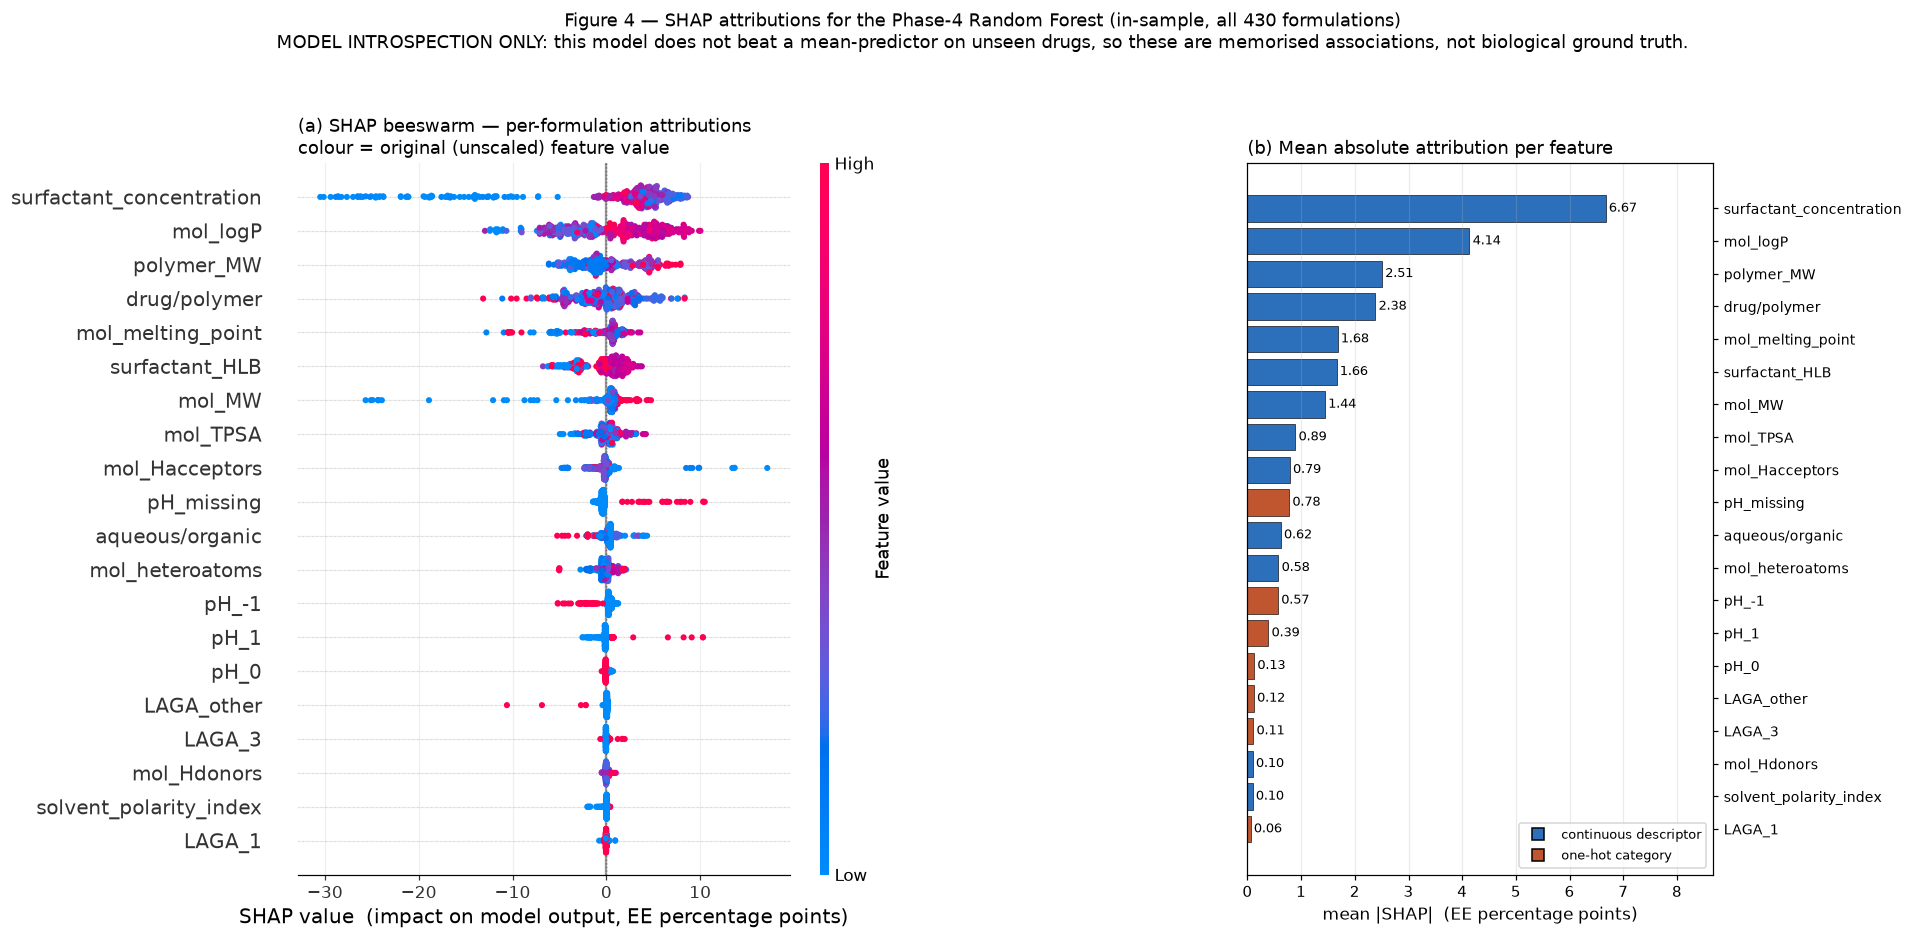

>>> SAVED: C:\Users\Ali sheroz\Desktop\PLGA-EE-Generalization\results\figures\Fig4_SHAP_summary.png (676,277 bytes, 300 DPI)


In [4]:
fig = plt.figure(figsize=(16.6, 8.4))
gs  = fig.add_gridspec(1, 2, width_ratios=[1.32, 1.0], wspace=0.62)

# --- (a) beeswarm, drawn by shap into our axes ---
ax_bee = fig.add_subplot(gs[0, 0])
plt.sca(ax_bee)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    shap.summary_plot(shap_values, X, feature_names=FEATURES,
                      max_display=len(FEATURES), show=False, plot_size=None,
                      color_bar=True, sort=True)
ax_bee = plt.gca()
ax_bee.set_xlabel("SHAP value  (impact on model output, EE percentage points)")
ax_bee.set_title("(a) SHAP beeswarm — per-formulation attributions\n"
                 "colour = original (unscaled) feature value", loc="left")
ax_bee.axvline(0, color="0.35", lw=0.9, ls=":", zorder=0)
ax_bee.grid(axis="x", alpha=0.20)

# --- (b) mean |SHAP| bar chart, y labels on the RIGHT to stay clear of the colour bar ---
ax_bar = fig.add_subplot(gs[0, 1])
bar = mean_abs.sort_values("mean_abs_SHAP_EE_pct")          # ascending -> largest on top
colors = np.where(bar["feature"].isin(CONTINUOUS), "#2c6fbb", "#c0562f")
ax_bar.barh(bar["feature"], bar["mean_abs_SHAP_EE_pct"], color=colors,
            edgecolor="black", linewidth=0.4)
for f, v in zip(bar["feature"], bar["mean_abs_SHAP_EE_pct"]):
    ax_bar.text(v + 0.06, f, f"{v:.2f}", va="center", ha="left", fontsize=8.2)
ax_bar.set_xlim(0, mean_abs["mean_abs_SHAP_EE_pct"].max() * 1.30)
ax_bar.set_xlabel("mean |SHAP|  (EE percentage points)")
ax_bar.set_title("(b) Mean absolute attribution per feature", loc="left")
ax_bar.yaxis.tick_right()
ax_bar.tick_params(axis="y", labelsize=9)
ax_bar.grid(axis="x", alpha=0.25); ax_bar.grid(axis="y", visible=False)
ax_bar.legend(handles=[Line2D([0], [0], marker="s", ls="", markerfacecolor="#2c6fbb",
                              markeredgecolor="black", markersize=8, label="continuous descriptor"),
                       Line2D([0], [0], marker="s", ls="", markerfacecolor="#c0562f",
                              markeredgecolor="black", markersize=8, label="one-hot category")],
              loc="lower right", frameon=True, fontsize=8.6)

fig.suptitle("Figure 4 — SHAP attributions for the Phase-4 Random Forest (in-sample, all 430 formulations)\n"
             "MODEL INTROSPECTION ONLY: this model does not beat a mean-predictor on unseen drugs, "
             "so these are memorised associations, not biological ground truth.",
             fontsize=11.5, y=1.045)
F4 = FIG / "Fig4_SHAP_summary.png"
fig.savefig(F4, dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show(); plt.close(fig)
print(">>> SAVED:", F4, f"({F4.stat().st_size:,} bytes, {DPI} DPI)")

## 3. Out-of-fold predictions for the error analysis

To locate the failures we need a prediction for every formulation made while **its entire drug was held out**. We regenerate them with the same Random Forest pipeline specification (`StandardScaler` → `RandomForestRegressor`, defaults, `random_state=42`) — never the full-data refit, whose predictions would be in-sample and near-perfect.

Two sets of out-of-fold predictions are produced:

- **`det`** — the single deterministic `GroupKFold(n_splits=5)` partition used for model selection in Phase 4. Reported so this notebook reconciles exactly with `ML_grouped_performance_metrics.csv`.
- **`rep`** — repeated grouped CV over the same 5 shuffled seeds as the Phase-4 robustness check. Each formulation is predicted 5 times, once per partition. **The per-drug error analysis is based on this**, because a single partition confounds "the model cannot predict this drug" with "this drug happened to be held out alongside an unhelpful set of companions".

A mean-predictor (`DummyRegressor`) is run through the identical splits so that each drug's error can be compared against the error of simply guessing the training mean. Without that reference, a large MAE cannot be distinguished from a drug whose EE% is merely far from average.

In [5]:
def make_rf():
    return Pipeline([("scaler", StandardScaler()),
                     ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))])

def make_dummy():
    return Pipeline([("scaler", StandardScaler()),
                     ("model", DummyRegressor(strategy="mean"))])

def oof_predictions(make_pipe, splits):
    """Out-of-fold predictions: each row predicted while its whole drug_group is held out."""
    pred = np.full(len(y), np.nan)
    for tr, te in splits:
        assert not (set(groups[tr]) & set(groups[te])),  "drug_group leaked across the split!"
        assert not (set(names[tr])  & set(names[te])),   "small_molecule_name leaked across the split!"
        p = make_pipe(); p.fit(X.iloc[tr], y[tr])
        pred[te] = p.predict(X.iloc[te])
    assert np.isfinite(pred).all(), "OOF predictions incomplete."
    return pred

split_sets = {"det": list(GroupKFold(n_splits=N_SPLITS).split(X, y, groups=groups))}
for s in SEEDS:
    split_sets[f"rep{s}"] = list(
        GroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=s).split(X, y, groups=groups))

oof_rf, oof_dm = {}, {}
for tag, sp in split_sets.items():
    oof_rf[tag] = oof_predictions(make_rf,    sp)
    oof_dm[tag] = oof_predictions(make_dummy, sp)
    print(f"  {tag:<6} RF  MAE {mean_absolute_error(y, oof_rf[tag]):6.3f} | "
          f"R2 {r2_score(y, oof_rf[tag]):+7.3f}   ||   "
          f"mean-predictor MAE {mean_absolute_error(y, oof_dm[tag]):6.3f}")

REP = [f"rep{s}" for s in SEEDS]
P_rf_rep = np.column_stack([oof_rf[t] for t in REP])      # 430 x 5
P_dm_rep = np.column_stack([oof_dm[t] for t in REP])
AE_rf    = np.abs(P_rf_rep - y[:, None])                  # abs error per formulation per seed
AE_dm    = np.abs(P_dm_rep - y[:, None])

print("\nLeakage assertions PASS for all folds of all 6 partitions "
      f"({len(split_sets)} partitions x {N_SPLITS} folds x 2 estimators = "
      f"{len(split_sets)*N_SPLITS*2} fits).")
print(f"Reconciliation with Phase 4: deterministic-partition pooled OOF MAE "
      f"{mean_absolute_error(y, oof_rf['det']):.3f} "
      f"(leaderboard OOF_MAE 16.695) | repeated-mean pooled MAE {AE_rf.mean():.3f} "
      f"(Phase-4 pooled 20.710)")

  det    RF  MAE 16.695 | R2  +0.170   ||   mean-predictor MAE 19.257


  rep0   RF  MAE 21.374 | R2  -0.449   ||   mean-predictor MAE 18.831


  rep1   RF  MAE 18.244 | R2  +0.046   ||   mean-predictor MAE 19.043


  rep2   RF  MAE 25.939 | R2  -1.139   ||   mean-predictor MAE 19.588


  rep3   RF  MAE 19.608 | R2  -0.037   ||   mean-predictor MAE 19.087


  rep4   RF  MAE 18.387 | R2  +0.083   ||   mean-predictor MAE 19.142

Leakage assertions PASS for all folds of all 6 partitions (6 partitions x 5 folds x 2 estimators = 60 fits).
Reconciliation with Phase 4: deterministic-partition pooled OOF MAE 16.695 (leaderboard OOF_MAE 16.695) | repeated-mean pooled MAE 20.710 (Phase-4 pooled 20.710)


In [6]:
# --- Per-formulation error table (row-level, saved for reproducibility of the figures) ---
per_form = pd.DataFrame({
    "row_id": df["row_id"], "small_molecule_name": names, "drug_group": groups,
    "reference": df["reference"], "EE_actual": y,
    "pred_det": oof_rf["det"], "abs_err_det": np.abs(oof_rf["det"] - y),
    "pred_rep_mean": P_rf_rep.mean(axis=1),
    "abs_err_rep_mean": AE_rf.mean(axis=1),
    "abs_err_rep_SD":   AE_rf.std(axis=1, ddof=1),
    "abs_err_mean_predictor_rep": AE_dm.mean(axis=1),
    "EE_is_zero": df["EE_is_zero"],
})
for i, s in enumerate(SEEDS):
    per_form[f"pred_rep_seed{s}"]    = P_rf_rep[:, i]
    per_form[f"abs_err_rep_seed{s}"] = AE_rf[:, i]
per_form["signed_err_rep_mean"] = per_form["pred_rep_mean"] - per_form["EE_actual"]
per_form.to_csv(TAB / "OOF_predictions_random_forest.csv", index=False)
print("Saved per-formulation OOF predictions ->", (TAB / "OOF_predictions_random_forest.csv").name)
print(f"\nPrediction range collapse (regression to the mean):")
print(f"   actual EE%          : {y.min():5.1f} – {y.max():5.1f}  (SD {y.std(ddof=1):.1f})")
print(f"   OOF predicted EE%   : {per_form['pred_rep_mean'].min():5.1f} – "
      f"{per_form['pred_rep_mean'].max():5.1f}  (SD {per_form['pred_rep_mean'].std(ddof=1):.1f})")
display(per_form[["small_molecule_name","drug_group","EE_actual","pred_det","pred_rep_mean",
                  "abs_err_rep_mean","abs_err_mean_predictor_rep"]].head(6).round(2))

Saved per-formulation OOF predictions -> OOF_predictions_random_forest.csv

Prediction range collapse (regression to the mean):
   actual EE%          :   0.0 –  98.9  (SD 23.5)
   OOF predicted EE%   :   8.7 –  83.5  (SD 13.9)


,small_molecule_name,drug_group,EE_actual,pred_det,pred_rep_mean,abs_err_rep_mean,abs_err_mean_predictor_rep
0,sparfloxacin,sparfloxacin,25.18,53.88,59.84,34.66,39.55
1,sparfloxacin,sparfloxacin,44.83,56.73,62.60,17.77,19.90
2,sparfloxacin,sparfloxacin,51.83,55.94,55.20,3.50,12.90
3,sparfloxacin,sparfloxacin,86.60,68.73,66.71,19.89,21.87
4,sparfloxacin,sparfloxacin,60.60,62.15,58.48,4.68,4.13
5,diazepam,diazepam,82.00,70.77,68.77,13.23,17.72


## 4. Error analysis by drug — where does the model actually fail?

Aggregating to `drug_group` gives, for each drug, the MAE it incurs when it is an **unseen** drug. Columns worth reading carefully:

- **`MAE_repeated`** — the headline per-drug MAE: mean absolute OOF error over all that drug's formulations and all 5 shuffled partitions. This is the ranking criterion.
- **`MAE_single_partition`** — the same quantity on the one deterministic partition, for reconciliation with Phase 4. Large gaps between the two columns are themselves a finding: they mean the drug's error depends heavily on which other drugs shared its training set.
- **`MAE_mean_predictor`** — the error a training-mean guess incurs for that drug.
- **`delta_vs_mean_predictor`** = `MAE_repeated − MAE_mean_predictor`. **Positive means the model is actively worse than guessing the average** for that drug; negative means the model genuinely helps there. This column is what separates *"a hard drug"* from *"a drug the model gets wrong"*.
- **`n_formulations`** — essential context. Half the drug groups are singletons, so a single-formulation drug's MAE rests on one measurement and is not an estimate of anything stable.

In [7]:
by_drug = (per_form.groupby("drug_group")
           .agg(n_formulations=("EE_actual", "size"),
                n_studies=("reference", "nunique"),
                EE_mean=("EE_actual", "mean"),
                EE_min=("EE_actual", "min"),
                EE_max=("EE_actual", "max"),
                EE_SD=("EE_actual", lambda s: s.std(ddof=1) if len(s) > 1 else np.nan),
                pred_rep_mean=("pred_rep_mean", "mean"),
                MAE_repeated=("abs_err_rep_mean", "mean"),
                MAE_single_partition=("abs_err_det", "mean"),
                mean_signed_error=("signed_err_rep_mean", "mean"),
                MAE_mean_predictor=("abs_err_mean_predictor_rep", "mean"))
           .reset_index())
by_drug["delta_vs_mean_predictor"] = by_drug["MAE_repeated"] - by_drug["MAE_mean_predictor"]
by_drug["model_worse_than_mean_predictor"] = by_drug["delta_vs_mean_predictor"] > 0
by_drug["is_singleton_drug"] = by_drug["n_formulations"] == 1
by_drug["bias_direction"] = np.where(by_drug["mean_signed_error"] > 0, "over-predicts", "under-predicts")
# Quartiles of the drug-group mean EE%, defined by the data (not chosen by eye after seeing errors).
by_drug["EE_quartile"] = pd.qcut(by_drug["EE_mean"], 4,
                                 labels=["Q1_lowest_EE", "Q2", "Q3", "Q4_highest_EE"]).astype(str)

by_drug = by_drug.sort_values("MAE_repeated", ascending=False).reset_index(drop=True)
by_drug.insert(0, "rank_worst_to_best", np.arange(1, len(by_drug) + 1))
by_drug["is_top5_worst"] = by_drug["rank_worst_to_best"] <= 5
by_drug["is_top5_best"]  = by_drug["rank_worst_to_best"] > len(by_drug) - 5
by_drug["cv_strategy"] = f"repeated GroupKFold(n_splits={N_SPLITS}, shuffle=True) over seeds {SEEDS}"
by_drug["model"] = meta["selected_model"]
by_drug["target"] = TARGET

EA_PATH = TAB / "Error_analysis_by_drug.csv"
by_drug.to_csv(EA_PATH, index=False)

SHOW = ["rank_worst_to_best","drug_group","n_formulations","EE_mean","EE_min","EE_max",
        "pred_rep_mean","MAE_repeated","MAE_single_partition","MAE_mean_predictor",
        "delta_vs_mean_predictor","bias_direction"]
worst5 = by_drug.head(5).copy()
best5  = by_drug.tail(5).sort_values("MAE_repeated").copy()

print("=" * 118)
print("TOP 5 WORST-PREDICTED DRUGS  (highest out-of-fold MAE as an unseen drug)")
print("=" * 118)
print(worst5[SHOW].to_string(index=False, float_format=lambda v: f"{v:8.2f}"))
print("\n" + "=" * 118)
print("TOP 5 BEST-PREDICTED DRUGS  (lowest out-of-fold MAE as an unseen drug)")
print("=" * 118)
print(best5[SHOW].to_string(index=False, float_format=lambda v: f"{v:8.2f}"))
print("=" * 118)
print(">>> SAVED:", EA_PATH)

TOP 5 WORST-PREDICTED DRUGS  (highest out-of-fold MAE as an unseen drug)
 rank_worst_to_best   drug_group  n_formulations  EE_mean   EE_min   EE_max  pred_rep_mean  MAE_repeated  MAE_single_partition  MAE_mean_predictor  delta_vs_mean_predictor bias_direction
                  1   ketoprofen               2    10.56     7.91    13.21          83.34         72.78                 68.31               54.79                    17.99  over-predicts
                  2      paeonol               1    86.26    86.26    86.26          31.65         54.61                 49.98               22.44                    32.17 under-predicts
                  3    tretinoin               1    98.80    98.80    98.80          44.41         54.39                 68.76               33.32                    21.06 under-predicts
                  4 levofloxacin               1    15.00    15.00    15.00          66.86         51.86                 51.14               49.44                     2.42  over-p


TOP 5 BEST-PREDICTED DRUGS  (lowest out-of-fold MAE as an unseen drug)
 rank_worst_to_best               drug_group  n_formulations  EE_mean   EE_min   EE_max  pred_rep_mean  MAE_repeated  MAE_single_partition  MAE_mean_predictor  delta_vs_mean_predictor bias_direction
                 63                rapamycin               1    74.25    74.25    74.25          70.74          3.77                  3.16                9.11                    -5.35 under-predicts
                 62                isoniazid               1    10.00    10.00    10.00          15.28          5.28                 17.99               53.94                   -48.66  over-predicts
                 61            rhodamine-123               1    55.30    55.30    55.30          59.62          5.92                 10.14               10.95                    -5.02  over-predicts
                 60               kartogenin               1    62.00    62.00    62.00          62.59          6.44                

In [8]:
# --- Context that decides how the top-5 lists may be interpreted ---
from scipy import stats

n_groups = len(by_drug)
n_worse  = int(by_drug["model_worse_than_mean_predictor"].sum())
n_singl  = int(by_drug["is_singleton_drug"].sum())

print(f"Drug groups: {n_groups} | singletons (n=1 formulation): {n_singl} ({100*n_singl/n_groups:.0f}%)")
print(f"Drug groups where the model is WORSE than a training-mean guess: {n_worse}/{n_groups} "
      f"({100*n_worse/n_groups:.0f}%)")
print(f"  ... among the 5 worst: {int(worst5['model_worse_than_mean_predictor'].sum())}/5"
      f" | among the 5 best: {int(best5['model_worse_than_mean_predictor'].sum())}/5")
print(f"Singletons among the 5 worst: {int(worst5['is_singleton_drug'].sum())}/5"
      f" | among the 5 best: {int(best5['is_singleton_drug'].sum())}/5")
print("  -> every drug in the 'best' list is a singleton, so each of those MAEs rests on ONE")
print("     measurement. Read that list as 'not yet contradicted', not as 'solved'.")

# --- EVIDENCE 1: shrinkage. The calibration slope is the decisive, assumption-light statistic. ---
slope, intercept, r_cal, p_cal, se_cal = stats.linregress(y, per_form["pred_rep_mean"])
print("\n" + "-" * 98)
print("EVIDENCE 1 - prediction shrinkage toward the training mean")
print(f"   calibration slope of OOF prediction on measurement : {slope:.3f}   (1.000 = calibrated)")
print(f"   SD of predictions {per_form['pred_rep_mean'].std(ddof=1):5.2f}  vs  SD of measurements "
      f"{y.std(ddof=1):5.2f} EE%")
print(f"   predicted range {per_form['pred_rep_mean'].min():.1f}-{per_form['pred_rep_mean'].max():.1f}"
      f"  vs  measured {y.min():.1f}-{y.max():.1f} EE%")
print("   A slope far below 1 means the model barely departs from its training mean - what a model")
print("   does when its features carry little usable information about a drug it has never seen.")

# --- EVIDENCE 2: is the error simply 'distance from the dataset mean'? Tested, not assumed. ---
dist = np.abs(by_drug["EE_mean"] - y.mean())
r_p, p_p = stats.pearsonr(dist, by_drug["MAE_repeated"])
rho, p_s = stats.spearmanr(dist, by_drug["MAE_repeated"])
print("-" * 98)
print("EVIDENCE 2 - per-drug MAE vs |drug mean EE% - dataset mean EE%|")
print(f"   Pearson  r   = {r_p:+.3f}  (p = {p_p:.3f})")
print(f"   Spearman rho = {rho:+.3f}  (p = {p_s:.3f})")
print(f"   NOT significant at the drug-group level (n = {n_groups}). So the failure is NOT a simple")
print("   symmetric function of distance from the mean. It is ASYMMETRIC - see EVIDENCE 3.")

# --- EVIDENCE 3: stratify by the drug's own EE% level, using data-defined quartiles. ---
strat = (by_drug.groupby("EE_quartile", observed=True)
         .agg(n_groups=("drug_group", "size"),
              drug_mean_EE_range=("EE_mean", lambda s: f"{s.min():.1f}-{s.max():.1f}"),
              median_MAE=("MAE_repeated", "median"),
              mean_MAE=("MAE_repeated", "mean"),
              mean_signed_error=("mean_signed_error", "mean"),
              mean_delta_vs_mean_predictor=("delta_vs_mean_predictor", "mean"),
              n_worse_than_mean_predictor=("model_worse_than_mean_predictor", "sum"))
         .reset_index())
strat.to_csv(TAB / "Error_analysis_by_EE_quartile.csv", index=False)
print("-" * 98)
print("EVIDENCE 3 - per-drug error stratified by the drug's own mean EE% (quartiles of the "
      f"{n_groups} groups)")
display(strat.round(2))
print("`mean_signed_error` runs monotonically from strongly POSITIVE (over-predicts the low-EE drugs)")
print("to strongly NEGATIVE (under-predicts the high-EE drugs): textbook shrinkage to the mean.")
print("Now read the SIGN of `mean_delta_vs_mean_predictor`. The model genuinely HELPS on the lowest-EE")
print("quartile - where a mean guess is hopeless - and genuinely HURTS on the top two quartiles.")
print("Those two effects nearly cancel, which is precisely how a model can win on one partition and")
print(f"lose on average: net {AE_rf.mean() - AE_dm.mean():+.2f} EE% versus the mean-predictor overall.")
print("-" * 98)

Drug groups: 63 | singletons (n=1 formulation): 32 (51%)
Drug groups where the model is WORSE than a training-mean guess: 32/63 (51%)
  ... among the 5 worst: 5/5 | among the 5 best: 1/5
Singletons among the 5 worst: 3/5 | among the 5 best: 5/5
  -> every drug in the 'best' list is a singleton, so each of those MAEs rests on ONE
     measurement. Read that list as 'not yet contradicted', not as 'solved'.

--------------------------------------------------------------------------------------------------
EVIDENCE 1 - prediction shrinkage toward the training mean
   calibration slope of OOF prediction on measurement : 0.156   (1.000 = calibrated)
   SD of predictions 13.94  vs  SD of measurements 23.51 EE%
   predicted range 8.7-83.5  vs  measured 0.0-98.9 EE%
   A slope far below 1 means the model barely departs from its training mean - what a model
   does when its features carry little usable information about a drug it has never seen.
--------------------------------------------------

,EE_quartile,n_groups,drug_mean_EE_range,median_MAE,mean_MAE,mean_signed_error,mean_delta_vs_mean_predictor,n_worse_than_mean_predictor
0,Q1_lowest_EE,16,0.3-33.0,16.07,22.49,20.95,-28.71,2
1,Q2,16,33.5-65.1,15.91,18.35,11.05,0.15,8
2,Q3,15,65.3-79.9,17.59,17.26,-11.42,6.43,11
3,Q4_highest_EE,16,80.5-98.8,27.10,32.30,-32.06,9.44,11


`mean_signed_error` runs monotonically from strongly POSITIVE (over-predicts the low-EE drugs)
to strongly NEGATIVE (under-predicts the high-EE drugs): textbook shrinkage to the mean.
Now read the SIGN of `mean_delta_vs_mean_predictor`. The model genuinely HELPS on the lowest-EE
quartile - where a mean guess is hopeless - and genuinely HURTS on the top two quartiles.
Those two effects nearly cancel, which is precisely how a model can win on one partition and
lose on average: net +1.57 EE% versus the mean-predictor overall.
--------------------------------------------------------------------------------------------------


### Figure 5 — Actual vs predicted EE% (out-of-fold, unseen drugs)

Panel **(a)** uses the single deterministic `GroupKFold(5)` partition (the Phase-4 selection partition); panel **(b)** uses the mean of the 5 shuffled partitions. Both show the perfect-prediction diagonal `y = x` and, for reference, the horizontal line a mean-predictor would produce. A model with transferable skill scatters *along the diagonal*; a model that has collapsed toward the dataset average scatters *along the horizontal*.

One reconciliation note, so panel (b) is not mistaken for a contradiction of Phase 4: its metrics are computed on the **seed-averaged prediction**, which is necessarily a little better than the average of the five individual partitions (averaging cancels partition-specific variance). That is why panel (b) reads MAE ≈ 20.0 while the Phase-4 pooled figure — the mean of the five per-partition MAEs — is 20.71. The per-drug analysis in §4 uses the stricter per-partition quantity.

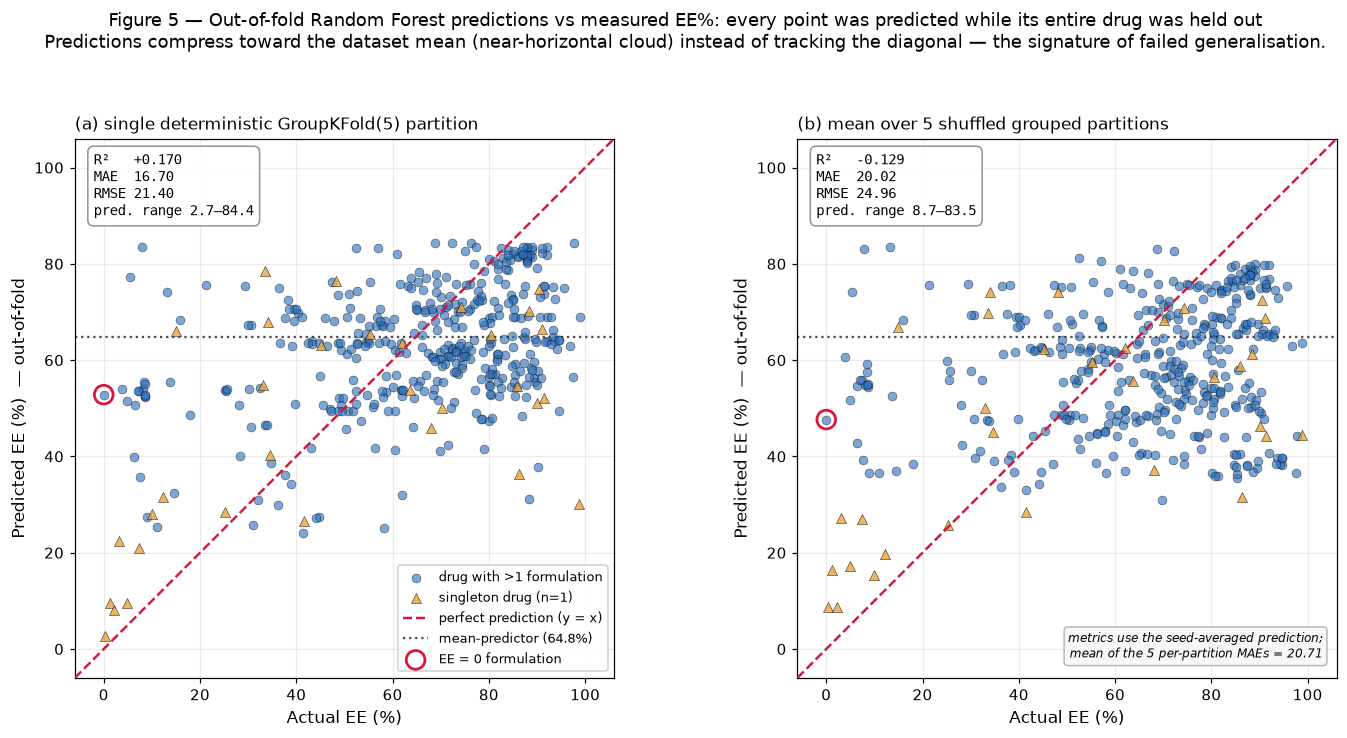

>>> SAVED: C:\Users\Ali sheroz\Desktop\PLGA-EE-Generalization\results\figures\Fig5_Actual_vs_Predicted_OOF.png (725,500 bytes, 300 DPI)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14.8, 6.7))
fig.subplots_adjust(wspace=0.34)
LIMS = (-6, 106)
panels = [("(a) single deterministic GroupKFold(5) partition", oof_rf["det"], "det"),
          (f"(b) mean over {len(SEEDS)} shuffled grouped partitions", P_rf_rep.mean(axis=1), "rep")]

for ax, (title, pred, tag) in zip(axes, panels):
    sing = by_drug.set_index("drug_group")["is_singleton_drug"].reindex(groups).to_numpy(bool)
    ax.scatter(y[~sing], pred[~sing], s=34, alpha=0.62, c="#2c6fbb",
               edgecolor="black", linewidth=0.35, label="drug with >1 formulation", zorder=3)
    ax.scatter(y[sing], pred[sing], s=44, alpha=0.80, c="#e8a33d", marker="^",
               edgecolor="black", linewidth=0.35, label="singleton drug (n=1)", zorder=4)
    ax.plot(LIMS, LIMS, ls="--", lw=1.6, color="crimson", zorder=5,
            label="perfect prediction (y = x)")
    ax.axhline(y.mean(), ls=":", lw=1.5, color="0.30", zorder=2,
               label=f"mean-predictor ({y.mean():.1f}%)")
    zero = df["EE_is_zero"].to_numpy(bool)
    ax.scatter(y[zero], pred[zero], s=150, facecolor="none", edgecolor="crimson",
               linewidth=1.8, zorder=6, label="EE = 0 formulation")

    txt = (f"R²   {r2_score(y, pred):+.3f}\n"
           f"MAE  {mean_absolute_error(y, pred):.2f}\n"
           f"RMSE {root_mean_squared_error(y, pred):.2f}\n"
           f"pred. range {pred.min():.1f}–{pred.max():.1f}")
    ax.text(0.035, 0.975, txt, transform=ax.transAxes, va="top", ha="left",
            fontsize=9.2, family="monospace",
            bbox=dict(boxstyle="round,pad=0.42", facecolor="white", edgecolor="0.55", alpha=0.94))
    ax.set_xlim(*LIMS); ax.set_ylim(*LIMS); ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual EE (%)"); ax.set_ylabel("Predicted EE (%)  — out-of-fold")
    ax.set_title(title, loc="left", fontsize=11)

axes[0].legend(loc="lower right", fontsize=8.4, framealpha=0.94)
axes[1].text(0.975, 0.03,
             f"metrics use the seed-averaged prediction;\n"
             f"mean of the 5 per-partition MAEs = {AE_rf.mean():.2f}",
             transform=axes[1].transAxes, va="bottom", ha="right", fontsize=8.0, style="italic",
             bbox=dict(boxstyle="round,pad=0.32", facecolor="#f7f7f7", edgecolor="0.7", alpha=0.94))
fig.suptitle("Figure 5 — Out-of-fold Random Forest predictions vs measured EE%: every point was predicted "
             "while its entire drug was held out\n"
             "Predictions compress toward the dataset mean (near-horizontal cloud) instead of tracking "
             "the diagonal — the signature of failed generalisation.",
             fontsize=11.5, y=1.035)
F5 = FIG / "Fig5_Actual_vs_Predicted_OOF.png"
fig.savefig(F5, dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show(); plt.close(fig)
print(">>> SAVED:", F5, f"({F5.stat().st_size:,} bytes, {DPI} DPI)")

### Figure 6 — Absolute-error distribution for the 5 worst-predicted drugs

Each box pools that drug's absolute out-of-fold errors over **all of its formulations × all 5 shuffled partitions**, so even a singleton drug contributes 5 values (one per partition) and the box shows how much its error depends on the partition. Individual points are overlaid because the counts are small and a box alone would hide that. Two vertical references are drawn: the mean-predictor's overall MAE and the Random Forest's overall MAE.

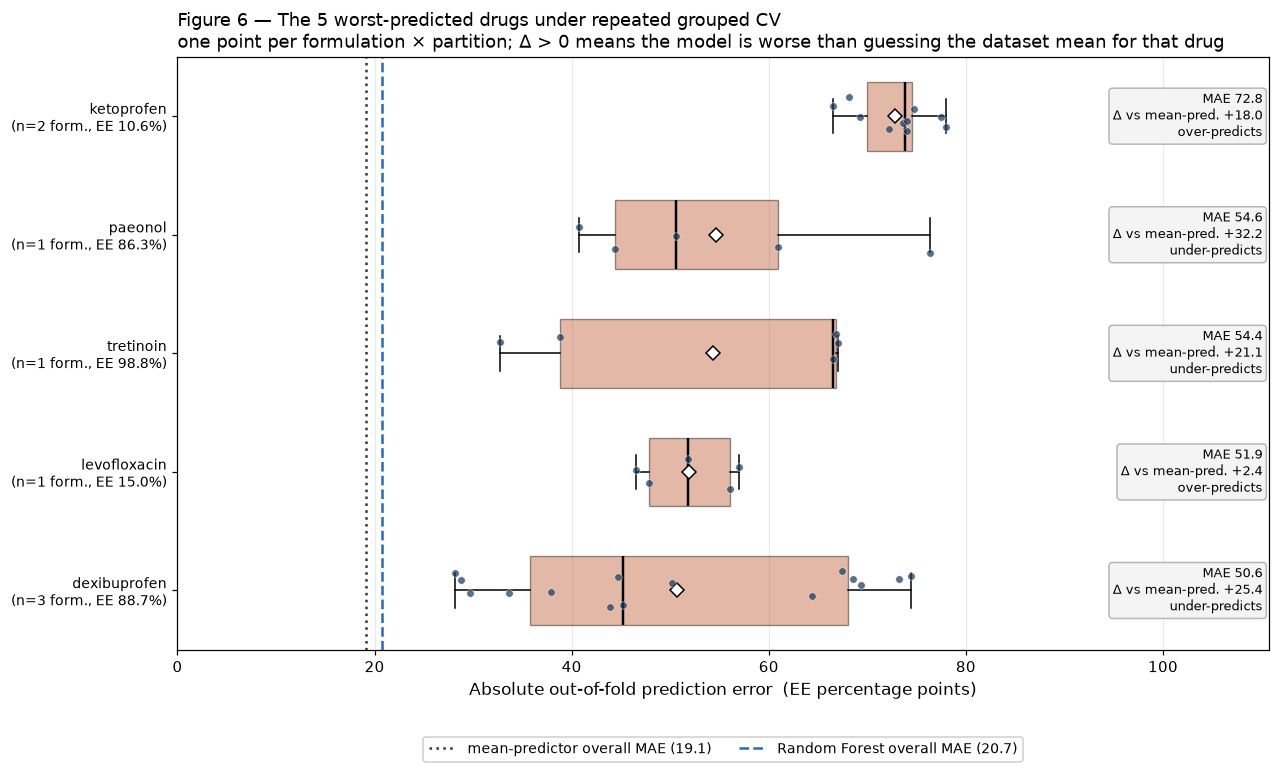

>>> SAVED: C:\Users\Ali sheroz\Desktop\PLGA-EE-Generalization\results\figures\Fig6_Worst_Predicted_Drugs.png (296,492 bytes, 300 DPI)


In [10]:
order = worst5["drug_group"].tolist()[::-1]                 # worst at the top of the axis
data, labels, meta_rows = [], [], []
for gname in order:
    m = (per_form["drug_group"] == gname).to_numpy()
    vals = AE_rf[m].ravel()                                 # formulations x seeds
    r = by_drug.loc[by_drug["drug_group"] == gname].iloc[0]
    data.append(vals)
    labels.append(f"{gname}\n(n={int(r['n_formulations'])} form., EE {r['EE_mean']:.1f}%)")
    meta_rows.append(r)

fig, ax = plt.subplots(figsize=(12.8, 7.0))
bp = ax.boxplot(data, orientation="horizontal", tick_labels=labels, widths=0.58,
                patch_artist=True, showmeans=True, showfliers=False,
                medianprops=dict(color="black", lw=1.6),
                meanprops=dict(marker="D", markerfacecolor="white",
                               markeredgecolor="black", markersize=6.5))
for patch in bp["boxes"]:
    patch.set(facecolor="#c0562f", alpha=0.42, edgecolor="black", linewidth=0.9)

rng = np.random.default_rng(RANDOM_STATE)
for i, vals in enumerate(data, start=1):
    ax.scatter(vals, i + rng.uniform(-0.17, 0.17, size=len(vals)), s=24, alpha=0.72,
               c="#1b3a5c", edgecolor="white", linewidth=0.4, zorder=4)

ax.axvline(AE_dm.mean(), ls=":", lw=1.7, color="0.25", zorder=1,
           label=f"mean-predictor overall MAE ({AE_dm.mean():.1f})")
ax.axvline(AE_rf.mean(), ls="--", lw=1.7, color="#2c6fbb", zorder=1,
           label=f"Random Forest overall MAE ({AE_rf.mean():.1f})")

xmax = max(v.max() for v in data)
ax.set_xlim(0, xmax * 1.42)
for i, r in enumerate(meta_rows, start=1):
    ax.text(xmax * 1.412, i,
            f"MAE {r['MAE_repeated']:.1f}\nΔ vs mean-pred. {r['delta_vs_mean_predictor']:+.1f}\n{r['bias_direction']}",
            va="center", ha="right", fontsize=8.3,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#f4f4f4", edgecolor="0.7", alpha=0.95))

ax.set_xlabel("Absolute out-of-fold prediction error  (EE percentage points)")
ax.set_ylabel("")
ax.set_title("Figure 6 — The 5 worst-predicted drugs under repeated grouped CV\n"
             "one point per formulation × partition; Δ > 0 means the model is worse than guessing "
             "the dataset mean for that drug",
             loc="left", fontsize=11.5)
ax.grid(axis="x", alpha=0.28); ax.grid(axis="y", visible=False)
# Legend placed BELOW the axes so it cannot cover the bottom drug's annotation box.
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.135), ncols=2,
          fontsize=9.0, framealpha=0.94)
ax.tick_params(axis="y", labelsize=9)
F6 = FIG / "Fig6_Worst_Predicted_Drugs.png"
fig.savefig(F6, dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show(); plt.close(fig)
print(">>> SAVED:", F6, f"({F6.stat().st_size:,} bytes, {DPI} DPI)")

In [11]:
# --- Verify every artefact is on disk at the required resolution ---
from PIL import Image
print("=" * 96)
print("PHASE 5 ARTEFACT VERIFICATION")
print("-" * 96)
for p in [F4, F5, F6]:
    with Image.open(p) as im:
        dpi = im.info.get("dpi", (None, None))
    ok = dpi and round(dpi[0]) == DPI and round(dpi[1]) == DPI
    print(f"  {'PASS' if ok else 'FAIL'}  {p.name:<38} {im.size[0]}x{im.size[1]} px  "
          f"dpi={tuple(round(d) for d in dpi)}  {p.stat().st_size:,} B")
    assert ok, f"{p.name} is not {DPI} DPI"
for p in [EA_PATH, TAB / "Error_analysis_by_EE_quartile.csv",
          TAB / "SHAP_feature_importance.csv", TAB / "OOF_predictions_random_forest.csv"]:
    print(f"  PASS  {p.name:<38} {p.stat().st_size:,} B  "
          f"({len(pd.read_csv(p))} rows)")
print("=" * 96)

PHASE 5 ARTEFACT VERIFICATION
------------------------------------------------------------------------------------------------
  PASS  Fig4_SHAP_summary.png                  5197x2562 px  dpi=(300, 300)  676,277 B
  PASS  Fig5_Actual_vs_Predicted_OOF.png       3673x2014 px  dpi=(300, 300)  725,500 B
  PASS  Fig6_Worst_Predicted_Drugs.png         3491x2105 px  dpi=(300, 300)  296,492 B
  PASS  Error_analysis_by_drug.csv             19,198 B  (63 rows)
  PASS  Error_analysis_by_EE_quartile.csv      530 B  (4 rows)
  PASS  SHAP_feature_importance.csv            2,086 B  (20 rows)


  PASS  OOF_predictions_random_forest.csv      160,612 B  (430 rows)


In [12]:
# --- Final summary ---
worst_line = " | ".join(f"{r.drug_group} ({r.MAE_repeated:.1f})" for r in worst5.itertuples())
best_line  = " | ".join(f"{r.drug_group} ({r.MAE_repeated:.1f})" for r in best5.itertuples())
top3_shap  = " > ".join(f"{r.feature} ({r.mean_abs_SHAP_EE_pct:.2f})" for r in mean_abs.head(3).itertuples())

print("=" * 100)
print("PHASE 5 SUMMARY — Explainability & Error Analysis")
print("=" * 100)
print(f"model examined        : {meta['selected_model']} (Phase-4 artefact, refit on all {len(y)} formulations)")
print(f"SHAP                  : TreeExplainer, in-sample, additivity verified ({max_dev:.1e} EE%)")
print(f"top-3 by mean |SHAP|  : {top3_shap}")
print( "                        ^ MEMORISED associations. Not biological ground truth: this model does")
print( "                          not beat a mean-predictor on unseen drugs (Phase 4).")
print("-" * 100)
print(f"OOF scheme            : repeated GroupKFold(5, shuffle=True), seeds {SEEDS} "
      f"({len(split_sets)*N_SPLITS*2} fits total)")
print(f"overall OOF MAE       : Random Forest {AE_rf.mean():.2f}  vs  mean-predictor {AE_dm.mean():.2f} EE%"
      f"  (net {AE_rf.mean()-AE_dm.mean():+.2f})")
print(f"calibration slope     : {slope:.3f} (1.0 = calibrated) -> predictions shrunk toward the mean")
print(f"prediction range      : {P_rf_rep.mean(axis=1).min():.1f}-{P_rf_rep.mean(axis=1).max():.1f} % "
      f"vs actual {y.min():.1f}-{y.max():.1f} %  (SD {P_rf_rep.mean(axis=1).std(ddof=1):.1f} vs {y.std(ddof=1):.1f})")
print(f"drugs worse than mean : {n_worse}/{n_groups} drug groups")
print(f"MAE vs |EE - mean|    : r = {r_p:+.3f} (p = {p_p:.3f}) -> NOT significant; the failure is")
print( "                        asymmetric, not a symmetric function of distance from the mean")
print( "asymmetry (quartiles) : over-predicts low-EE drugs (signed err "
      f"{strat.iloc[0]['mean_signed_error']:+.1f}), under-predicts high-EE drugs "
      f"({strat.iloc[-1]['mean_signed_error']:+.1f});")
print(f"                        beats the mean-predictor on Q1 ({strat.iloc[0]['mean_delta_vs_mean_predictor']:+.1f})"
      f" but loses on Q4 ({strat.iloc[-1]['mean_delta_vs_mean_predictor']:+.1f})")
print("-" * 100)
print("5 WORST (MAE, EE%):", worst_line)
print("5 BEST  (MAE, EE%):", best_line)
print("   (all 5 'best' drugs are singletons - one measurement each, not stable estimates)")
print("-" * 100)
print("saved:  results/figures/Fig4_SHAP_summary.png")
print("        results/figures/Fig5_Actual_vs_Predicted_OOF.png")
print("        results/figures/Fig6_Worst_Predicted_Drugs.png")
print("        results/tables/Error_analysis_by_drug.csv")
print("        results/tables/Error_analysis_by_EE_quartile.csv     (supporting)")
print("        results/tables/SHAP_feature_importance.csv           (supporting)")
print("        results/tables/OOF_predictions_random_forest.csv     (supporting, row-level)")
print("=" * 100)

PHASE 5 SUMMARY — Explainability & Error Analysis
model examined        : Random Forest (Phase-4 artefact, refit on all 430 formulations)
SHAP                  : TreeExplainer, in-sample, additivity verified (2.2e-13 EE%)
top-3 by mean |SHAP|  : surfactant_concentration (6.67) > mol_logP (4.14) > polymer_MW (2.51)
                        ^ MEMORISED associations. Not biological ground truth: this model does
                          not beat a mean-predictor on unseen drugs (Phase 4).
----------------------------------------------------------------------------------------------------
OOF scheme            : repeated GroupKFold(5, shuffle=True), seeds [0, 1, 2, 3, 4] (60 fits total)
overall OOF MAE       : Random Forest 20.71  vs  mean-predictor 19.14 EE%  (net +1.57)
calibration slope     : 0.156 (1.0 = calibrated) -> predictions shrunk toward the mean
prediction range      : 8.7-83.5 % vs actual 0.0-98.9 %  (SD 13.9 vs 23.5)
drugs worse than mean : 32/63 drug groups
MAE vs |EE - mean|

## Phase 5 complete

### What the error analysis shows

**The dominant failure mode is shrinkage, and it is quantified rather than asserted.** The calibration slope of the out-of-fold prediction on the measurement is **0.156** (a calibrated model gives 1.0): the predictions span roughly 9–84 % with SD 13.9 while the measurements span 0–98.9 % with SD 23.5. Absent usable information about a drug it has never seen, the model drifts toward the mean of its training drugs — which is exactly why it cannot beat an explicit mean-predictor.

**But the failure is asymmetric, not a symmetric "distance from the mean" effect.** That naive explanation was tested and does not hold: per-drug MAE is not significantly correlated with `|drug mean EE% − dataset mean EE%|` at the drug-group level (Pearson r = +0.20, p = 0.11; Spearman ρ = +0.23, p = 0.08, n = 63). Stratifying by quartiles of drug-group mean EE% shows what is actually happening — mean signed error runs monotonically from **+21** EE% in the lowest-EE quartile (over-prediction) to **−32** EE% in the highest (under-prediction), and the comparison against the mean-predictor flips sign across the range:

| Quartile of drug mean EE% | n groups | median MAE | mean signed error | mean Δ vs mean-predictor |
|---|---|---|---|---|
| Q1 (0.3–33.0 %) | 16 | 16.1 | **+21.0** (over) | **−28.7** → model helps a lot |
| Q2 (33.5–65.1 %) | 16 | 15.9 | +11.1 | +0.2 → a wash |
| Q3 (65.3–79.9 %) | 15 | 17.6 | −11.4 | +6.4 → model hurts |
| Q4 (80.5–98.8 %) | 16 | **27.1** | **−32.1** (under) | **+9.4** → model hurts most |

So the model is **not uniformly useless**: on the lowest-EE quartile it substantially beats a mean guess, because a mean guess of 64.8 % is hopeless for a drug that encapsulates at 10 %. It loses on the upper half, where it refuses to commit to genuinely high EE% values. Those two effects nearly cancel, leaving a net **+1.6 EE%** *worse* than the mean-predictor overall. **This is the mechanism behind Phase 4's negative result** — and it explains how the same pipeline can win convincingly on one partition and lose on the next, depending on how the extreme drugs happen to fall.

Two further cautions on the top-5 lists:

1. **All five best-predicted drugs are singletons.** Each of those MAEs rests on a single measurement, so the list identifies drugs that have not yet contradicted the model, not drugs the model has solved.
2. **Sample size does not buy safety.** Well-represented drugs still fail badly when *all* of their formulations are withheld at once — `flurbiprofen` (36 formulations) has a repeated-CV MAE of 41.4 versus 20.7 on the deterministic partition, because removing that block removes a large share of the training signal. The gap between the `MAE_repeated` and `MAE_single_partition` columns is itself diagnostic.

### Constraints on any claim taken from this notebook
- The SHAP ranking is **in-sample model introspection**. It is not evidence about biology, mechanism, or causation, and it is not backed by out-of-fold predictive skill.
- Descriptor, drug and study identity are largely confounded here (62/65 drugs appear in a single publication), so an "important descriptor" may be a study fingerprint.
- No hyperparameter tuning was performed at any point, so none of these numbers is an upper bound on what a tuned model could achieve. Tuning must be nested *inside* the grouped CV.
- Per-drug MAE for a singleton drug is one measurement, not an estimate. The quartile table is reported at group level (n = 63) precisely so that heavily-represented drugs cannot dominate it.
- `EE` remains the sole target throughout; `LC` and `particle_size` were never available to the model.

### Sensible next steps (not run here)
Nested hyperparameter tuning inside the grouped CV; a study-level `GroupKFold` on `reference` to separate drug identity from study fingerprint; restricting claims to the well-populated logP 0–5 region; adding more drugs at the **EE% extremes specifically** — the quartile table shows that is where the information is missing, so more mid-range formulations would not help; and, since shrinkage rather than noise is the limiting factor, testing whether a coarse *classification* of EE% (low / medium / high) transfers to unseen drugs even where point regression does not.